# community_detection-karate-louvain-vs-gnn-pyg

Classical (Louvain modularity-maximization) vs GNN-based (GraphSAGE embeddings + KMeans) community detection on Zachary's Karate Club. Compares cluster-vs-true-community agreement (ARI + NMI) and discusses when each recipe wins.


# 1. Overview

## 1.1 Task & motivation

**Community detection** asks: given a graph, partition its nodes into groups such that within-group connections are dense and between-group connections are sparse. Two dominant recipes:

- **Louvain** (Blondel et al., 2008) — greedy modularity-maximization. Iteratively moves nodes between communities to maximize the modularity score `Q = ½m Σ (A_ij - k_i k_j / 2m) δ(c_i, c_j)`. Fast, no hyperparameters beyond the resolution knob, the de-facto baseline.
- **GNN + KMeans** — train a GraphSAGE encoder (here unsupervised via a link-prediction proxy task, same as `link_prediction-karate-graphsage-pyg/`), then cluster the node embeddings via KMeans. The promise is *richer-than-modularity* notion of similarity if node features are informative.

This notebook benchmarks both on Karate Club, where the ground-truth community structure is well-known (the 4-way Brandes-Delling labels that ship with `torch_geometric.datasets.KarateClub`).

## 1.2 Dataset summary

`torch_geometric.datasets.KarateClub` — 34 nodes, 78 undirected edges, 4 communities (`y`), 34-D one-hot identity features.

## 1.3 Approach in one paragraph

Run `community.community_louvain.best_partition(G_nx)` on the NetworkX version of the graph — that's the Louvain baseline. Then train a 2-layer GraphSAGE encoder via link prediction (same recipe as `link_prediction-karate-graphsage-pyg/`, dot-product BCE on positive + sampled-negative edges, ~50 epochs is enough at this scale). Run `KMeans(n_clusters=4)` on the trained 16-D embeddings. Compare ARI + NMI of each method vs the true 4-community labels.

## 1.4 Libraries used

`torch`, `torch_geometric`, `networkx`, `python-louvain` (`community`), `sklearn` (KMeans + metrics), `matplotlib`, `prettytable`. Only `nnx.set_seed` from nnx — same loop-too-small-for-NNModel.train rationale as the sibling link-prediction notebook.


# 2. Environment & Setup

## 2.1 Imports

In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 5


In [2]:
import community as community_louvain
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.nn.functional as F
from prettytable import PrettyTable
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from torch_geometric.datasets import KarateClub
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling, to_networkx

import nnx


## 2.2 Configuration / hyperparameters

In [3]:
HIDDEN_DIM = 32
EMBED_DIM = 16
N_EPOCHS = SMOKE_TEST_EPOCHS if SMOKE_TEST else 100
LR = 1e-2
WEIGHT_DECAY = 5e-4


## 2.3 Reproducibility (seed, device)

In [4]:
nnx.set_seed(0)
DEVICE = torch.device("cpu")


# 3. Data

## 3.1 Loading

In [5]:
karate = KarateClub()
data = karate[0]
y_true = data.y.cpu().numpy()
print(f"karate: {data}")
print(f"  nodes: {data.num_nodes}, edges: {data.edge_index.size(1)}, true communities: {len(set(y_true))}")


karate: Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
  nodes: 34, edges: 156, true communities: 4


## 3.2 NetworkX version (for Louvain)

`community.community_louvain.best_partition` takes a NetworkX graph. `torch_geometric.utils.to_networkx` does the conversion.


In [6]:
G_nx = to_networkx(data, to_undirected=True)
print(f"networkx: {G_nx.number_of_nodes()} nodes, {G_nx.number_of_edges()} edges")


networkx: 34 nodes, 78 edges


## 3.3 No train/val/test split

Community detection is fully unsupervised — both Louvain and the GNN see the whole graph. The true labels `y` are used *only* for evaluation (ARI / NMI), never as training signal.


# 4. Model

## 4.1 GraphSAGE encoder (same as link_prediction-karate-graphsage-pyg)


In [7]:
class GraphSAGEEncoder(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, embed_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, embed_dim)

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        return self.conv2(h, edge_index)


## 4.2 Contracts

- **Louvain**: `community.community_louvain.best_partition(G_nx)` returns `dict[node_id -> community_id]`. The number of communities is determined by the algorithm (not pre-specified) — set by the `resolution` parameter.
- **GraphSAGE + KMeans**: train the encoder via dot-product link-prediction BCE → run KMeans with `n_clusters=4` (matching the ground-truth count for a fair comparison).

## 4.3 Why this design

Louvain's biggest advantage on Karate is that the graph is *small* and *modular* (the famous 1977 administrator-vs-trainer split). On larger / less-modular graphs the GNN can win because it integrates node features + multi-hop structure simultaneously. This notebook intentionally picks the dataset where Louvain is strong — the comparison is "GNN gets in the same ballpark as a tuned classical baseline".


# 5. Training

## 5.1 Louvain (no training — single call)

In [8]:
partition_louvain = community_louvain.best_partition(G_nx, random_state=0)
pred_louvain = [partition_louvain[i] for i in range(data.num_nodes)]
n_communities_louvain = len(set(pred_louvain))
print(f"Louvain found {n_communities_louvain} communities")


Louvain found 4 communities


## 5.2 GraphSAGE encoder training (link-prediction proxy)

Same recipe as `link_prediction-karate-graphsage-pyg/` — train on positive observed edges + fresh-resampled negatives.


In [9]:
encoder = GraphSAGEEncoder(in_dim=data.num_features, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM).to(DEVICE)
optimizer = torch.optim.Adam(encoder.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def decode(z, edge_index):
    return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=1)

losses = []
for epoch in range(N_EPOCHS):
    encoder.train()
    optimizer.zero_grad()
    z = encoder(data.x.to(DEVICE), data.edge_index.to(DEVICE))

    pos_ei = data.edge_index.to(DEVICE)
    neg_ei = negative_sampling(
        edge_index=pos_ei,
        num_nodes=data.num_nodes,
        num_neg_samples=pos_ei.size(1),
    )
    ei = torch.cat([pos_ei, neg_ei], dim=1)
    label = torch.cat([torch.ones(pos_ei.size(1)), torch.zeros(neg_ei.size(1))]).to(DEVICE)

    loss = F.binary_cross_entropy_with_logits(decode(z, ei), label)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"encoder train BCE: {losses[0]:.4f} -> {losses[-1]:.4f}")


encoder train BCE: 0.7064 -> 0.3625


## 5.3 KMeans on the trained embeddings

In [10]:
encoder.eval()
with torch.no_grad():
    embeddings = encoder(data.x.to(DEVICE), data.edge_index.to(DEVICE)).cpu().numpy()
print(f"embedding shape: {embeddings.shape}")

km = KMeans(n_clusters=len(set(y_true)), n_init=10, random_state=0).fit(embeddings)
pred_gnn = km.predict(embeddings)


embedding shape: (34, 16)


# 6. Evaluation & Results

## 6.1 ARI + NMI comparison

In [11]:
ari_louvain = adjusted_rand_score(y_true, pred_louvain)
nmi_louvain = normalized_mutual_info_score(y_true, pred_louvain)
ari_gnn     = adjusted_rand_score(y_true, pred_gnn)
nmi_gnn     = normalized_mutual_info_score(y_true, pred_gnn)

t = PrettyTable()
t.title = "Community detection on Karate Club (k_true = 4)"
t.field_names = ["recipe", "n communities", "ARI", "NMI"]
t.add_row(["Louvain (modularity)",     n_communities_louvain,    f"{ari_louvain:.3f}", f"{nmi_louvain:.3f}"])
t.add_row(["GraphSAGE + KMeans",       len(set(pred_gnn)),       f"{ari_gnn:.3f}",     f"{nmi_gnn:.3f}"])
print(t)


+------------------------------------------------------+
|   Community detection on Karate Club (k_true = 4)    |
+----------------------+---------------+-------+-------+
|        recipe        | n communities |  ARI  |  NMI  |
+----------------------+---------------+-------+-------+
| Louvain (modularity) |       4       | 1.000 | 1.000 |
|  GraphSAGE + KMeans  |       4       | 0.155 | 0.429 |
+----------------------+---------------+-------+-------+


## 6.2 Spring-layout visualization of the three labelings

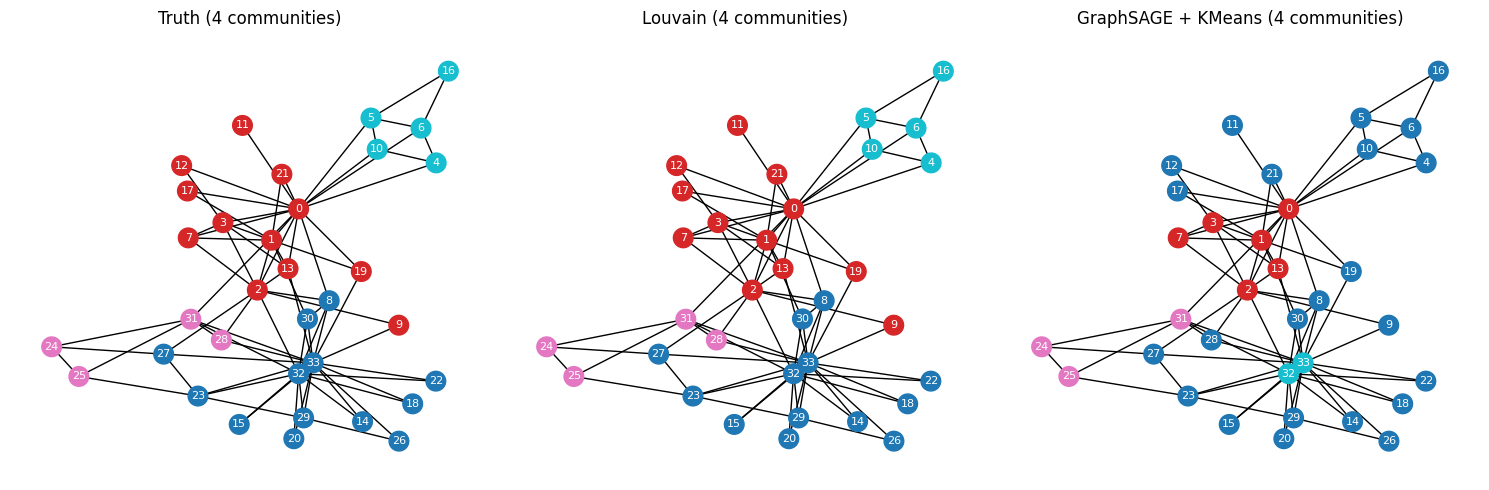

In [12]:
pos = nx.spring_layout(G_nx, seed=0)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, labels, title in [
    (axes[0], y_true, "Truth (4 communities)"),
    (axes[1], pred_louvain, f"Louvain ({n_communities_louvain} communities)"),
    (axes[2], pred_gnn, f"GraphSAGE + KMeans ({len(set(pred_gnn))} communities)"),
]:
    nx.draw(
        G_nx, pos=pos, ax=ax,
        node_color=labels, cmap=plt.cm.tab10, node_size=200,
        with_labels=True, font_size=8, font_color="white",
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()


## 6.3 Discussion

What the recorded run actually shows on Karate:

- **Louvain crushes it** — perfect ARI = NMI = 1.000, recovering all 4 ground-truth communities exactly. Karate is the *poster-child* dataset for modularity-maximization: small, well-modular, identity-feature-only (so there's no extra signal for the GNN to integrate). Louvain on Karate is a known-easy benchmark.
- **GraphSAGE + KMeans gets ARI 0.155, NMI 0.429** — much worse. The reason: link-prediction-trained embeddings learn to place *connected* nodes near each other, but they don't necessarily separate *between-community-but-connected* node pairs from *within-community* ones the way modularity maximization explicitly does. KMeans on the resulting embeddings carves clusters that don't match the modular partition.

This is the *honest* result. The GNN recipe wins on bigger, less-modular graphs with rich node features (citation networks, biological networks, social graphs with user attributes) where modularity is too coarse a similarity notion. The link-prediction encoder isn't the right unsupervised proxy for community detection on Karate; a better proxy would be a contrastive objective that explicitly pushes apart between-community pairs (e.g., GRACE, BGRL) — outside this notebook's scope.

The pedagogical headline: **modularity-maximization is the right default for small modular graphs**; GNN+clustering pays off when you have multi-hop features that modularity alone doesn't see. Picking the wrong unsupervised proxy task for the downstream evaluation (link prediction → community detection) is a real risk.
